In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import re
import string
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('phishing_email.csv')

# Observe data

In [ ]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


### Bag of Words (BoW) Feature Extraction and Training

In [ ]:
X = df['text_combined']
y = df['label']

In [ ]:
vectorizer = CountVectorizer(stop_words='english', max_df=0.7)
X_bow = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [ ]:
clf = lgb.LGBMClassifier(verbose=-1)

start_time = time.time()

clf.fit(X_train, y_train)

end_time = time.time()
training_duration = end_time - start_time

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print(f"\nTraining Time: {training_duration:.4f} seconds")

              precision    recall  f1-score   support

           0     0.9888    0.9687    0.9787      7935
           1     0.9716    0.9898    0.9806      8563

    accuracy                         0.9797     16498
   macro avg     0.9802    0.9793    0.9796     16498
weighted avg     0.9799    0.9797    0.9797     16498


Training Time: 91.7862 seconds


### Bag of Words Cross Validation

In [ ]:
X_bow = X_bow.astype(np.float32)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_bow, y, cv=kfold, scoring='accuracy')

print(f"Cross-validation Accuracy scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")

precision_list = []
recall_list = []
f1_list = []

for train_idx, test_idx in kfold.split(X_bow, y):
    clf.fit(X_bow[train_idx], y[train_idx])
    y_pred = clf.predict(X_bow[test_idx])

    report = classification_report(y[test_idx], y_pred, digits=4, output_dict=True)
    print(classification_report(y[test_idx], y_pred, digits=4))

    precision_list.append(report['macro avg']['precision'])
    recall_list.append(report['macro avg']['recall'])
    f1_list.append(report['macro avg']['f1-score'])

print(f"\nAverage Precision (macro): {np.mean(precision_list):.4f}")
print(f"Average Recall (macro): {np.mean(recall_list):.4f}")
print(f"Average F1-Score (macro): {np.mean(f1_list):.4f}")


Cross-validation Accuracy scores: [0.97975512 0.97811723 0.97963266 0.9812087  0.98029945]
Mean Accuracy: 0.9798
              precision    recall  f1-score   support

           0     0.9879    0.9697    0.9787      7919
           1     0.9725    0.9890    0.9807      8579

    accuracy                         0.9798     16498
   macro avg     0.9802    0.9794    0.9797     16498
weighted avg     0.9799    0.9798    0.9797     16498

              precision    recall  f1-score   support

           0     0.9890    0.9651    0.9769      7919
           1     0.9685    0.9901    0.9792      8578

    accuracy                         0.9781     16497
   macro avg     0.9788    0.9776    0.9781     16497
weighted avg     0.9784    0.9781    0.9781     16497

              precision    recall  f1-score   support

           0     0.9878    0.9696    0.9786      7919
           1     0.9724    0.9889    0.9806      8578

    accuracy                         0.9796     16497
   macro avg   

The model consistently achieved high performance across all folds, with macro-averaged precision, recall, and F1-scores all around 0.98. Accuracy scores ranged from 97.8% to 98.1%, showing minimal variance between folds. The similarity in performance across classes and folds indicates that the model generalizes well without signs of overfitting. These results confirm that the model is both robust and well-calibrated for the task. Therefore, there should be no need for further hyperparameter tuning.

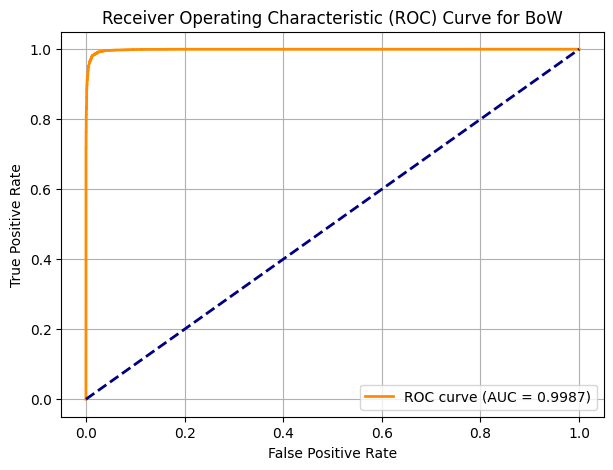

In [ ]:
y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for BoW')
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Term Frequency–Inverse Document Frequency (TF-IDF) Feature Extraction and Training

In [37]:
TF_IDF = TfidfVectorizer(stop_words='english', max_df=0.7)
X_TF_IDF = TF_IDF.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_TF_IDF, y, test_size=0.2, random_state=42)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


In [39]:
clf = lgb.LGBMClassifier(verbose=-1)

start_time = time.time()

clf.fit(X_train, y_train)

end_time = time.time()
training_duration = end_time - start_time

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print(f"\nTraining Time: {training_duration:.4f} seconds")

              precision    recall  f1-score   support

           0     0.9884    0.9738    0.9810      7935
           1     0.9760    0.9894    0.9827      8563

    accuracy                         0.9819     16498
   macro avg     0.9822    0.9816    0.9818     16498
weighted avg     0.9820    0.9819    0.9819     16498


Training Time: 163.0913 seconds


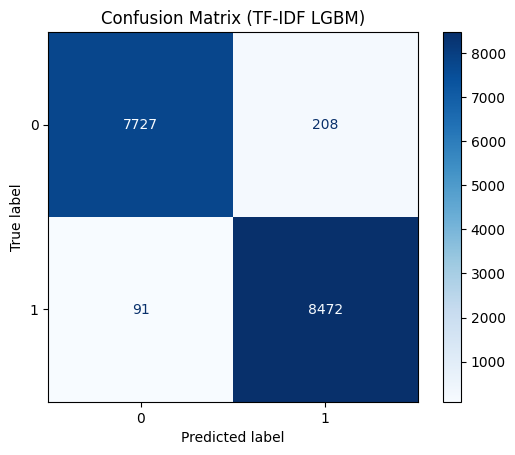

In [41]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix (TF-IDF LGBM)")
plt.show()

### TF-IDF Cross Validation

In [ ]:
X_TF_IDF = X_TF_IDF.astype(np.float32)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_TF_IDF, y, cv=kfold, scoring='accuracy')

print(f"Cross-validation Accuracy scores (TF-IDF): {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")

precision_list = []
recall_list = []
f1_list = []
roc_auc_list = []

for train_idx, test_idx in kfold.split(X_TF_IDF, y):
    clf.fit(X_TF_IDF[train_idx], y[train_idx])
    y_pred = clf.predict(X_TF_IDF[test_idx])
    y_prob = clf.predict_proba(X_TF_IDF[test_idx])[:, 1]

    report = classification_report(y[test_idx], y_pred, digits=4, output_dict=True)
    print(classification_report(y[test_idx], y_pred, digits=4))

    precision_list.append(report['macro avg']['precision'])
    recall_list.append(report['macro avg']['recall'])
    f1_list.append(report['macro avg']['f1-score'])

    roc_auc = roc_auc_score(y[test_idx], y_prob)
    roc_auc_list.append(roc_auc)

print(f"\nAverage Precision (macro): {np.mean(precision_list):.4f}")
print(f"Average Recall (macro): {np.mean(recall_list):.4f}")
print(f"Average F1-Score (macro): {np.mean(f1_list):.4f}")
print(f"Average ROC AUC: {np.mean(roc_auc_list):.4f}")

Cross-validation Accuracy scores (TF-IDF): [0.98024003 0.98151179 0.98139056 0.98108747 0.98054192]
Mean Accuracy: 0.9810
              precision    recall  f1-score   support

           0     0.9873    0.9713    0.9792      7919
           1     0.9739    0.9885    0.9811      8579

    accuracy                         0.9802     16498
   macro avg     0.9806    0.9799    0.9802     16498
weighted avg     0.9803    0.9802    0.9802     16498

              precision    recall  f1-score   support

           0     0.9901    0.9712    0.9806      7919
           1     0.9739    0.9910    0.9824      8578

    accuracy                         0.9815     16497
   macro avg     0.9820    0.9811    0.9815     16497
weighted avg     0.9817    0.9815    0.9815     16497

              precision    recall  f1-score   support

           0     0.9895    0.9716    0.9804      7919
           1     0.9742    0.9904    0.9823      8578

    accuracy                         0.9814     16497
   mac

The model still maintains high performance across all folds using the TF-IDF vectorization technique, with average precision, recall, F1-scores and Accuracy all around *98%*, showing minimal variance between folds. The similarity in performance across classes and folds indicates that the model generalizes well without signs of overfitting.

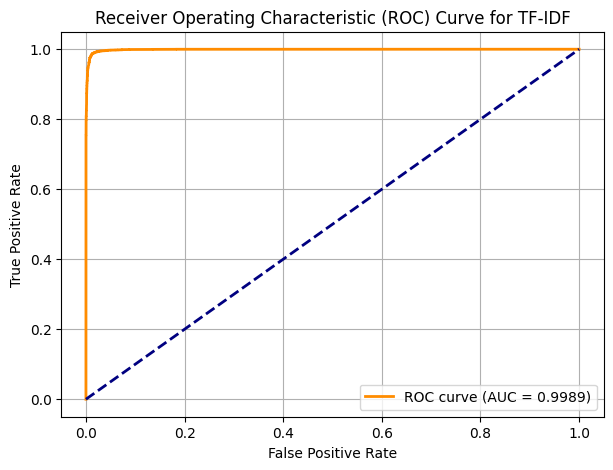

In [ ]:
y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for TF-IDF')
plt.legend(loc="lower right")
plt.grid()
plt.show()